# Swipe To Export
## Data Analysis & Exploratory Data Analysis (EDA)
This notebook performs exploratory analysis on the commodity trade dataset used for the Swipe-to-Export matchmaking system.

## 1. Import Libraries

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

## 2. Load Dataset

In [95]:
df = pd.read_csv('/content/sample_data/final_final_final_data.csv')
df.head()

,country_or_area,year,commodity,flow,trade_usd
0,China,2016,"Animals, live, except farm animals",Import,87264965
1,China,2016,"Animals, live, except farm animals",Export,55747455
2,China,2015,"Animals, live, except farm animals",Import,83102354
3,China,2015,"Animals, live, except farm animals",Export,37526715
4,China,2014,"Animals, live, except farm animals",Import,118595882


## 3. Select Relevant Columns

In [96]:
df = df[['country_or_area','year','commodity','flow','trade_usd']]
df.head()

,country_or_area,year,commodity,flow,trade_usd
0,China,2016,"Animals, live, except farm animals",Import,87264965
1,China,2016,"Animals, live, except farm animals",Export,55747455
2,China,2015,"Animals, live, except farm animals",Import,83102354
3,China,2015,"Animals, live, except farm animals",Export,37526715
4,China,2014,"Animals, live, except farm animals",Import,118595882


## 4. Dataset Overview

In [97]:
print('Dataset shape:', df.shape)
print('\nColumn types:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Dataset shape: (5287, 5)

Column types:
country_or_area    object
year                int64
commodity          object
flow               object
trade_usd           int64
dtype: object

Missing values:
country_or_area    0
year               0
commodity          0
flow               0
trade_usd          0
dtype: int64


## 5. Data Cleaning

In [98]:
df = df.dropna()
df = df.drop_duplicates()
df.shape

(5287, 5)

## 6. Summary Statistics

In [99]:
df.describe()

,year,trade_usd
count,5287.000000,5.287000e+03
mean,2013.482126,1.254933e+08
std,1.713827,4.074567e+08
min,2011.000000,2.000000e+00
25%,2012.000000,1.006018e+06
50%,2013.000000,1.377324e+07
75%,2015.000000,7.741052e+07
max,2016.000000,7.754818e+09


## 7. Export vs Import Distribution

In [100]:
flow_counts = df['flow'].value_counts()
flow_counts

,count
flow,
Export,2660
Import,2627


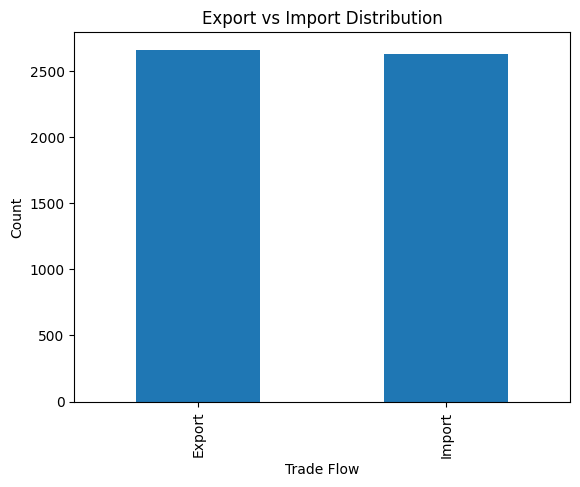

In [101]:
flow_counts.plot(kind='bar')
plt.title('Export vs Import Distribution')
plt.xlabel('Trade Flow')
plt.ylabel('Count')
plt.show()

## 8. Top Exporting Countries

In [102]:
exports = df[df['flow']=='Export']
top_exporters = exports.groupby('country_or_area')['trade_usd'].sum().sort_values(ascending=False).head(10)
top_exporters

,trade_usd
country_or_area,
Germany,72444167480
China,71131471274
France,63301084518
Netherlands,60589181598
New Zealand,57261658654
India,49014544457
USA,14008934914
United Arab Emirates,1552496590
Japan,776349928


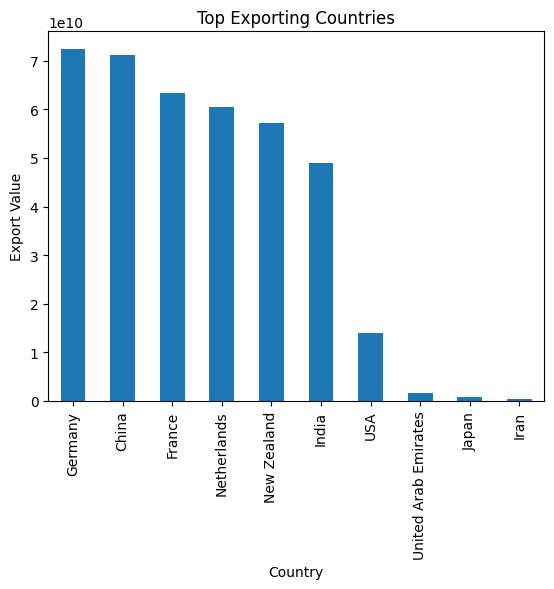

In [103]:
top_exporters.plot(kind='bar')
plt.title('Top Exporting Countries')
plt.xlabel('Country')
plt.ylabel('Export Value')
plt.show()

## 9. Top Importing Countries

In [104]:
imports = df[df['flow']=='Import']
top_importers = imports.groupby('country_or_area')['trade_usd'].sum().sort_values(ascending=False).head(10)
top_importers

,trade_usd
country_or_area,
Germany,89686091290
China,56376915179
France,55305425787
Netherlands,27408900109
Japan,20956955637
USA,12502860403
United Arab Emirates,4497286186
Singapore,1764788185
India,1524001944


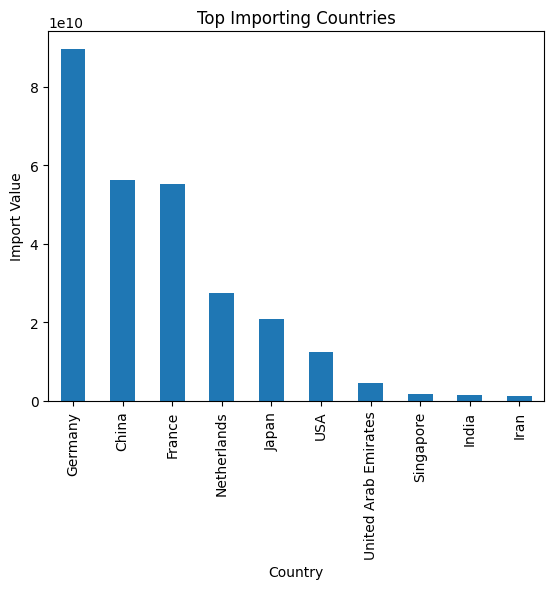

In [105]:
top_importers.plot(kind='bar')
plt.title('Top Importing Countries')
plt.xlabel('Country')
plt.ylabel('Import Value')
plt.show()

## 10. Most Traded Commodities

In [106]:
top_products = df.groupby('commodity')['trade_usd'].sum().sort_values(ascending=False).head(10)
top_products

,trade_usd
commodity,
"Cheese except fresh, grated, processed or blue-veined",89112716834
"Rice, semi-milled or wholly milled",72091219124
Milk and cream powder unsweetened < 1.5% fat,46405261607
"Coffee, not roasted, not decaffeinated",43593704379
Butter and other fats and oils derived from milk,37711802148
Milk powder < 1.5% fat,28646268359
Milk not concentrated nor sweetened 1-6% fat,20231882349
Whey,20116257863
"Apples, fresh",16046524415


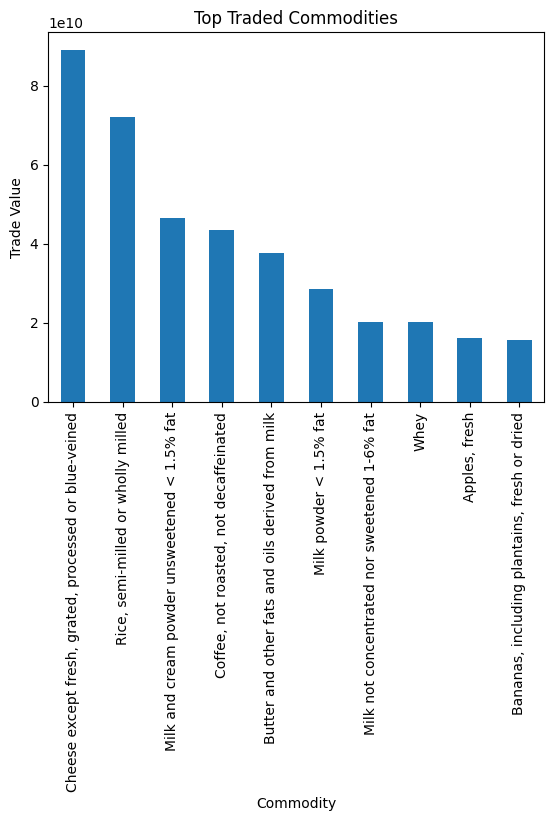

In [107]:
top_products.plot(kind='bar')
plt.title('Top Traded Commodities')
plt.xlabel('Commodity')
plt.ylabel('Trade Value')
plt.show()

## 11. Commodity Search Example

In [108]:
def search_commodity(keyword):
    keyword = keyword.lower()
    options = [c for c in df['commodity'].unique() if keyword in c.lower()]
    return options

options = search_commodity('coffee')

In [109]:
for i, option in enumerate(options):
    print(f"{i}: {option}")

0: Coffee, not roasted, not decaffeinated
1: Coffee, not roasted, decaffeinated
2: Coffee, roasted, decaffeinated


## 12. Select Commodity Type

In [110]:
choice = int(input(f"Select option (0 to {len(options)-1}): "))

Select option (0 to 2): 2


In [111]:
if choice < 0 or choice >= len(options):
    print("Invalid choice. Try again.")
else:
    selected_commodity = options[choice]
    print("Selected:", selected_commodity)

Selected: Coffee, roasted, decaffeinated


In [112]:
filtered = df[df['commodity'] == selected_commodity]

## 13. Import / Export Split

In [113]:
imports = filtered[filtered['flow'] == 'Import']
exports = filtered[filtered['flow'] == 'Export']

## 14. Feature Engineering

In [114]:
import_val = imports.groupby('country_or_area')['trade_usd'].sum()
export_val = exports.groupby('country_or_area')['trade_usd'].sum()

ml_data = pd.DataFrame({
    'import_value': import_val,
    'export_value': export_val
}).fillna(0)

ml_data['demand_gap'] = ml_data['import_value'] - ml_data['export_value']
ml_data['import_ratio'] = ml_data['import_value'] / (ml_data['export_value'] + 1)
ml_data['dependency'] = ml_data['demand_gap'] / (ml_data['import_value'] + 1)

## 15. Target Variable

In [115]:
ml_data['target'] = (ml_data['demand_gap'] > 0).astype(int)

## 16. Train Logistic Regression

In [116]:
X = ml_data[['import_value','export_value','import_ratio','dependency']]
y = ml_data['target']

model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

## 17. Predict Probabilities


In [117]:
ml_data['probability'] = model.predict_proba(X)[:,1]

## 18. Final Recommedation

In [136]:
def recommend_markets(top_n=5):
    result = ml_data.sort_values(by='probability', ascending=False).head(top_n)
    result = result.reset_index()  # bring country as column
    result['Rank'] = result.index + 1

    final = result[['Rank', 'country_or_area', 'probability']]

    return final.set_index('Rank')

recommend_markets()

,country_or_area,probability
Rank,,
1,France,0.73
2,Japan,0.73
3,Germany,0.71
4,Iran,0.43
5,China,0.10


## 12. Key Insights
- Identify major exporters and importers
- Identify high-demand commodities
- Understand trade patterns used for matchmaking
- These insights help build the ML recommendation system